# 09. Calibration + QEM

在带显式读出噪声的 dummy adapter 上运行读出校准，将校准结果写入临时缓存，再用 `ReadoutEM` 对同一个 noisy backend 产生的观测 counts 做修正。


assignment fidelity: 0.9
confusion matrix: [[0.92, 0.12], [0.08, 0.88]]
observed: {0: 24, 1: 176}
corrected: {0: 0.0, 1: 200.0}


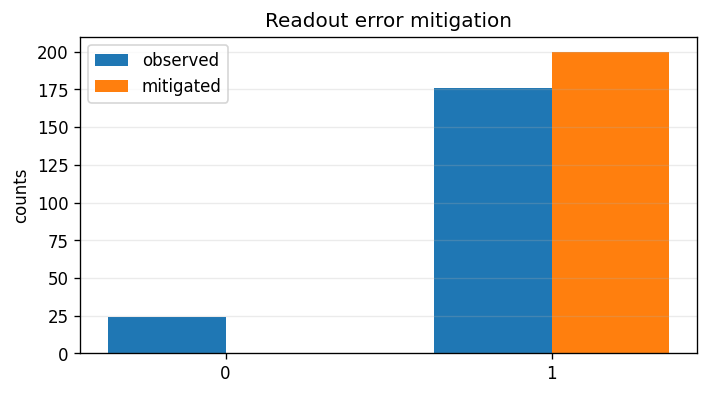

In [1]:
import tempfile
import matplotlib.pyplot as plt

from uniqc import Circuit
from uniqc.backend_adapter.task.adapters import DummyAdapter
from uniqc.calibration.readout import ReadoutCalibrator
from uniqc.qem import ReadoutEM

cache_dir = tempfile.mkdtemp(prefix="uniqc-bp-calibration-")
adapter = DummyAdapter(noise_model={"readout": [0.08, 0.12]})
calibrator = ReadoutCalibrator(adapter=adapter, shots=200, cache_dir=cache_dir)
calibration = calibrator.calibrate_1q(0)

observed_circuit = Circuit(1)
observed_circuit.x(0)
observed_circuit.measure(0)
task_id = adapter.submit(observed_circuit.originir, shots=200)
raw_counts = adapter.query(task_id)["result"]
observed = {int(k, 2): v for k, v in raw_counts.items()}
mitigator = ReadoutEM(adapter=adapter, shots=200, cache_dir=cache_dir)
corrected = mitigator.mitigate_counts(observed, measured_qubits=[0])

print("assignment fidelity:", round(calibration["assignment_fidelity"], 4))
print("confusion matrix:", calibration["confusion_matrix"])
print("observed:", observed)
print("corrected:", {k: round(v, 2) for k, v in corrected.items()})

labels = ["0", "1"]
fig, ax = plt.subplots(figsize=(6, 3.4))
x = range(len(labels))
ax.bar([i - 0.18 for i in x], [observed[i] for i in x], width=0.36, label="observed")
ax.bar([i + 0.18 for i in x], [corrected[i] for i in x], width=0.36, label="mitigated")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("counts")
ax.set_title("Readout error mitigation")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
